# *Lab DL / Project 4*

## import data

### Imports

In [ ]:
import os
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Seeds

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### conecting

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### Dataset Path

In [ ]:
import os

print(os.path.exists("/content/Currency.zip"))

False


In [ ]:
print(os.listdir("/content"))

['.config', 'currency_model.keras', 'drive', 'sample_data']


In [ ]:
import shutil

drive_zip_path = "/content/drive/MyDrive/Currency.zip"

# The file is already in Google Drive, no need to copy it from /content
# shutil.copy("/content/Currency.zip", drive_zip_path)

print("Currency.zip found in Google Drive!")

Currency.zip found in Google Drive!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(os.listdir('/content/drive/MyDrive'))

['IMG_8602.jpeg', 'IMG_8603.jpeg', 'Colab Notebooks', 'IMG_8345.jpeg', 'DSI_kickstarterscrape_dataset (2).gsheet', 'DSI_kickstarterscrape_dataset (1).gsheet', 'DSI_kickstarterscrape_dataset.gsheet', 'Untitled presentation.gslides', 'Classroom', 'CV - GA.pdf', 'fatima_awachi_02_ML_reg_ex (3).ipynb', 'fatima_awachi_02_ML_reg_ex (2).ipynb', 'fatima_awachi_02_ML_reg_ex (1).ipynb', 'fatima_awachi_02_ML_reg_ex.ipynb', 'Fatima Mahmood A.Awachi CV.pdf', 'Currency.zip', 'currency_data', 'currency_model_data', 'currency_model.keras', 'app.py']


In [ ]:
print(os.path.exists(drive_zip_path))

True


In [ ]:
zip_path = "/content/drive/MyDrive/Currency.zip"

In [ ]:
extract_path = "/content/drive/MyDrive/currency_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir(extract_path))

['Currency']


In [ ]:
currency_path = "/content/drive/MyDrive/currency_data/Currency"

print(os.listdir(currency_path))

['0.05', '0.100', '0.25', '0.5 BD', '0.50', '10 BD', '1BD', '20 BD', '5 BD']


In [ ]:
for folder in os.listdir(currency_path):
    folder_path = os.path.join(currency_path, folder)

    print(folder, "->", os.listdir(folder_path)[:10])

0.05 -> ['Test', 'Train']
0.100 -> ['Test', 'Train']
0.25 -> ['Test', 'Train']
0.5 BD -> ['Test', 'Train']
0.50 -> ['Test', 'Train']
10 BD -> ['Test', 'Train']
1BD -> ['Test', 'Train']
20 BD -> ['Test', 'Train']
5 BD -> ['Test', 'Train']


In [ ]:
train_path = "/content/drive/MyDrive/currency_data/Currency"
test_path = "/content/drive/MyDrive/currency_data/Currency"

In [ ]:
for folder in os.listdir(currency_path):
    train_folder = os.path.join(currency_path, folder, "Train")
    test_folder = os.path.join(currency_path, folder, "Test")

    train_images = len(os.listdir(train_folder))
    test_images = len(os.listdir(test_folder))

    print(folder, "-> Train:", train_images, "| Test:", test_images)

0.05 -> Train: 40 | Test: 10
0.100 -> Train: 35 | Test: 10
0.25 -> Train: 40 | Test: 11
0.5 BD -> Train: 40 | Test: 8
0.50 -> Train: 40 | Test: 10
10 BD -> Train: 40 | Test: 10
1BD -> Train: 50 | Test: 12
20 BD -> Train: 42 | Test: 13
5 BD -> Train: 50 | Test: 13


In [ ]:
model_data_path = "/content/drive/MyDrive/currency_model_data"

train_model_path = os.path.join(model_data_path, "Train")
test_model_path = os.path.join(model_data_path, "Test")

os.makedirs(train_model_path, exist_ok=True)
os.makedirs(test_model_path, exist_ok=True)

In [ ]:
for folder in os.listdir(currency_path):

    original_train = os.path.join(currency_path, folder, "Train")
    original_test = os.path.join(currency_path, folder, "Test")

    new_train = os.path.join(train_model_path, folder)
    new_test = os.path.join(test_model_path, folder)

    os.makedirs(new_train, exist_ok=True)
    os.makedirs(new_test, exist_ok=True)

    for file in os.listdir(original_train):
        shutil.copy(
            os.path.join(original_train, file),
            os.path.join(new_train, file)
        )

    for file in os.listdir(original_test):
        shutil.copy(
            os.path.join(original_test, file),
            os.path.join(new_test, file)
        )

print("Dataset prepared successfully!")

Dataset prepared successfully!


In [ ]:
print(os.listdir(train_model_path))
print(os.listdir(test_model_path))

['0.05', '0.100', '0.25', '0.5 BD', '0.50', '10 BD', '1BD', '20 BD', '5 BD']
['0.05', '0.100', '0.25', '0.5 BD', '0.50', '10 BD', '1BD', '20 BD', '5 BD']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1/255
)

test_datagen = ImageDataGenerator(
    rescale=1/255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_model_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 377 images belonging to 9 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_model_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 97 images belonging to 9 classes.


In [ ]:
# Preprocessing

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2)
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_model_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_model_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)
print("Number of classes:", len(class_names))


Found 377 images belonging to 9 classes.
Found 97 images belonging to 9 classes.
Classes: ['0.05', '0.100', '0.25', '0.5 BD', '0.50', '10 BD', '1BD', '20 BD', '5 BD']
Number of classes: 9


## Model Training

In [ ]:
# Step 1
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Step 2
model = Sequential()

model.add(Flatten(input_shape=(224, 224, 3)))  # image 3D -> 1D

model.add(Dense(500, activation='relu'))  # hidden layer
model.add(Dense(200, activation='relu'))  # hidden layer
model.add(Dense(100, activation='relu'))  # hidden layer

model.add(Dense(len(class_names), activation='softmax'))  # output layer


model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │     1,354,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,354,761 (5.17 MB)

 Trainable params: 1,354,761 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 3: Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Step 4: Fitting (Learning)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50
)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 856ms/step - accuracy: 0.1194 - loss: 91.3185 - val_accuracy: 0.0825 - val_loss: 85.0575
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 738ms/step - accuracy: 0.1061 - loss: 51.7548 - val_accuracy: 0.1856 - val_loss: 33.4162
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 774ms/step - accuracy: 0.1698 - loss: 32.0298 - val_accuracy: 0.1031 - val_loss: 29.1930
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 672ms/step - accuracy: 0.1883 - loss: 23.0047 - val_accuracy: 0.1031 - val_loss: 27.2797
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 733ms/step - accuracy: 0.2095 - loss: 21.7538 - val_accuracy: 0.2371 - val_loss: 18.6566
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 741ms/step - accuracy: 0.2997 - loss: 12.4401 - val_accuracy: 0.1959 - val_loss: 11.9514
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 717ms/step - accuracy: 0.3103 - loss: 9.6422 - val_accuracy: 0.2990 - val_loss: 9.6666
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 775ms/step - accuracy: 0.3316 - loss: 8.4671 - va

In [ ]:
# history
history_df = pd.DataFrame(history.history)
history_df


,accuracy,loss,val_accuracy,val_loss
0,0.119363,91.318512,0.082474,85.057503
1,0.106101,51.754803,0.185567,33.416168
2,0.169761,32.029785,0.103093,29.192959
3,0.188329,23.004725,0.103093,27.279684
4,0.209549,21.753796,0.237113,18.656614
5,0.299735,12.440125,0.195876,11.951373
6,0.310345,9.642160,0.298969,9.666633
7,0.331565,8.467147,0.226804,9.598401
8,0.270557,11.924255,0.216495,29.925783
9,0.193634,20.126860,0.185567,23.625284


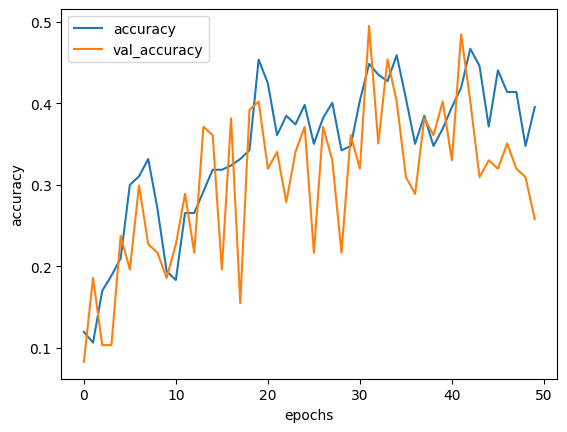

In [ ]:
history_df[['accuracy', 'val_accuracy']].plot()
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()


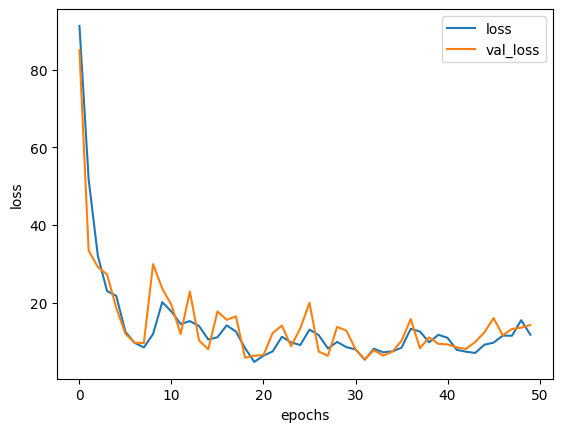

In [ ]:
history_df[["loss", "val_loss"]].plot()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()


## Evaluation

In [ ]:
# Step 5: Prediction

test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_label = np.argmax(y_pred, axis=1)
y_test = test_generator.classes

print("Accuracy:", accuracy_score(y_test, y_pred_label))


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step
Accuracy: 0.25773195876288657


In [ ]:
model.evaluate(test_generator)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 0.2577 - loss: 14.2421


[14.242101669311523, 0.25773194432258606]

In [ ]:
print(classification_report(
    y_test,
    y_pred_label,
    target_names=class_names
))


              precision    recall  f1-score   support

        0.05       0.24      1.00      0.38        10
       0.100       0.40      0.20      0.27        10
        0.25       0.00      0.00      0.00        11
      0.5 BD       0.00      0.00      0.00         8
        0.50       1.00      0.10      0.18        10
       10 BD       0.17      0.70      0.27        10
         1BD       0.00      0.00      0.00        12
       20 BD       0.00      0.00      0.00        13
        5 BD       1.00      0.38      0.56        13

    accuracy                           0.26        97
   macro avg       0.31      0.26      0.18        97
weighted avg       0.32      0.26      0.19        97



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_label)
conf_matrix


array([[10,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  2,  0,  0,  0,  4,  0,  0,  0],
       [11,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 7,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 5,  0,  1,  0,  1,  3,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  7,  0,  0,  0],
       [ 1,  2,  1,  0,  0,  8,  0,  0,  0],
       [ 1,  0,  0,  0,  0, 12,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  8,  0,  0,  5]])

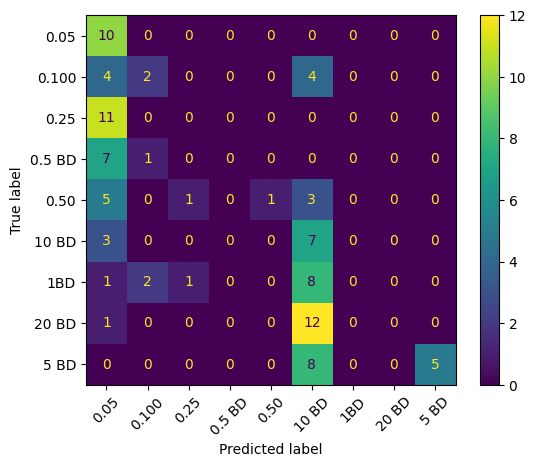

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_label,
    display_labels=class_names,
    xticks_rotation=45
)
plt.show()


## Error Analysis

In [ ]:
idx = np.where(y_test != y_pred_label)[0]
print("Number of wrong predictions:", len(idx))
idx[:25]


Number of wrong predictions: 72


array([10, 11, 12, 13, 14, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33, 34, 35, 36])

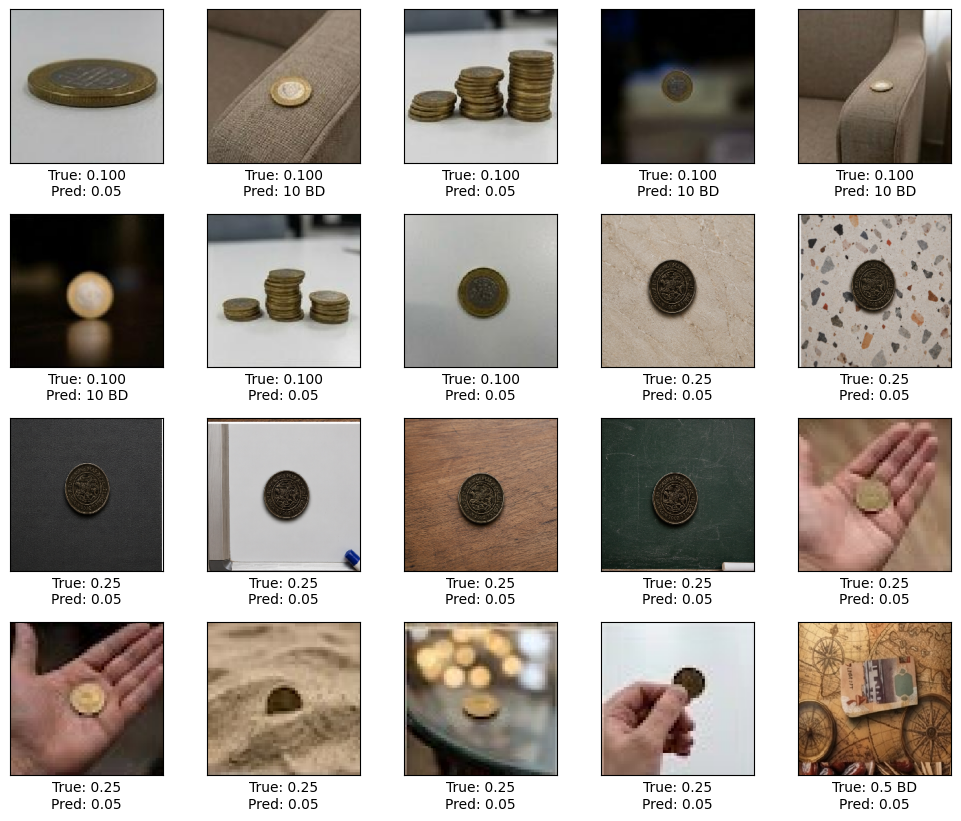

In [ ]:
# Show some images the model got wrong

test_generator.reset()
images, labels = next(test_generator)

plt.figure(figsize=(10, 10))

shown = 0
for i in range(len(images)):
    if y_test[i] != y_pred_label[i]:
        plt.subplot(5, 5, shown + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i])
        plt.xlabel(
            f"True: {class_names[y_test[i]]}\n"
            f"Pred: {class_names[y_pred_label[i]]}"
        )
        shown += 1
        if shown == 25:
            break

plt.tight_layout()
plt.show()


## Key Questions

In [ ]:
print("Most confused classes can be seen in the confusion matrix above.")
print("Similar-looking notes can be checked from the misclassified images.")
print("Background effects can be checked using new images with unseen backgrounds.")


Most confused classes can be seen in the confusion matrix above.
Similar-looking notes can be checked from the misclassified images.
Background effects can be checked using new images with unseen backgrounds.


## Streamlit Deployment + API

In [ ]:
model.save("currency_model.keras")

In [ ]:
from google.colab import files

files.download('/content/currency_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save the trained model

model.save("/content/drive/MyDrive/currency_model.keras")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
# Create Streamlit app

app_code = '''
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf

model = tf.keras.models.load_model("currency_model.keras")

class_names = %r

st.title("Bahraini Currency Recognition")

uploaded_file = st.file_uploader("Upload a currency image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)

    image = image.resize((224, 224))
    image_array = np.array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]

    st.write("Prediction:", class_names[predicted_class])
    st.write("Confidence:", float(confidence))
''' % class_names

with open("/content/drive/MyDrive/app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")


app.py created successfully!


## Final Reflection

1. Why did classification work well initially?
2. What problems did object detection solve?
3. Which approach is more suitable for real-world deployment?
4. How would you improve the system further?


## Notes

The dataset used in this notebook contains 9 currency classes. The model output layer therefore uses the number of classes detected from the dataset.
